# KMeans 개선안 4: k 후보 범위 확대

`k=2~6`만 확인하던 범위를 `k=2~10`으로 넓혀 더 다양한 군집 수 후보를 비교합니다.

In [ ]:
from pathlib import Path
from urllib.request import urlretrieve

data_path = Path('fruits_300.npy')
if not data_path.exists():
    urlretrieve('https://bit.ly/fruits_300_data', data_path)


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

fruits = np.load('fruits_300.npy')
fruits_2d = fruits.reshape(-1, 100 * 100) / 255.0


labels: (array([0, 1], dtype=int32), array([201,  99]))
labels: (array([0, 1, 2], dtype=int32), array([ 91,  98, 111]))
labels: (array([0, 1, 2, 3], dtype=int32), array([ 41,  90,  58, 111]))
labels: (array([0, 1, 2, 3, 4], dtype=int32), array([ 16,  91, 110,  32,  51]))
labels: (array([0, 1, 2, 3, 4, 5], dtype=int32), array([ 16,  51,  51, 110,  32,  40]))
labels: (array([0, 1, 2, 3, 4, 5, 6], dtype=int32), array([ 41,  35, 110,  32,  50,  16,  16]))
labels: (array([0, 1, 2, 3, 4, 5, 6, 7], dtype=int32), array([32, 51, 54, 57, 16, 39, 16, 35]))
labels: (array([0, 1, 2, 3, 4, 5, 6, 7, 8], dtype=int32), array([54, 31, 37, 37, 16, 26, 48, 16, 35]))
labels: (array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=int32), array([50, 31, 13, 16, 48, 16, 54, 21, 37, 14]))


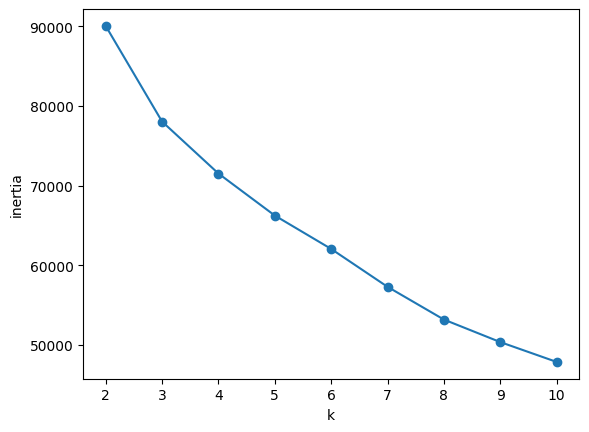

In [3]:
k_values = range(2, 11)
inertia = []

for k in k_values:
    km = KMeans(n_clusters=k, n_init=20, random_state=42)
    km.fit(fruits_2d)
    print('labels:', np.unique(km.labels_, return_counts=True))
    inertia.append(km.inertia_)

plt.plot(k_values, inertia, marker='o')
plt.xlabel('k')
plt.ylabel('inertia')
plt.xticks(list(k_values))
plt.show()
